# Esame Laboratorio di Programmazione II - 03/02/2026


Scrivete chiaramente sul notebook il vostro nome e matricola e salvate il file con il nome della vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, ogni cella deve avere il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## Esercizio 1

Un sensore ha registrato le seguenti misure (in unità arbitrarie) in 15 istanti consecutivi:

`12, 15, 14, 18, 21, 19, 17, 16, 22, 25, 20, 18, 16, 15, 14`

1. Crea un array NumPy `x` con questi valori e calcola la **media**.
2. Per un problema di calibrazione, tutte le misure **strettamente maggiori di 18** devono essere **ridotte di 2**. Aggiorna l’array (in-place) e stampa il nuovo array.  
3. Calcola quanti valori, dopo la correzione, risultano **compresi tra 14 e 18 inclusi**.  


In [2]:
#1
x = np.array([12, 15, 14, 18, 21, 19, 17, 16, 22, 25, 20, 18, 16, 15, 14])
media = np.mean(x)
print("Media array: ", media)
#2
condizione = x > 18
x[condizione] = x[condizione] - 2
print("Array calibrato : \n", x)
#3
vero_falso = (x>=14) & (x<=18)
somma = np.sum(vero_falso)
print("Valori compresi tra 14 e 18: ", somma)


Media array:  17.466666666666665
Array calibrato : 
 [12 15 14 18 19 17 17 16 20 23 18 18 16 15 14]
Valori compresi tra 14 e 18:  11


## Esercizio 2

Un dado **truccato** ha probabilità **doppia** di uscire 6 rispetto agli altri numeri.

In particolare:
- la probabilità di ottenere ciascun numero da **1 a 5** è **1/7**
- la probabilità di ottenere **6** è **2/7**

1. Scrivi una funzione `lanci_dado(N)` che simula `N` lanci del dado e restituisce
   un array NumPy contenente i risultati.
2. Per valori di `N = 50, 100, 150, ..., 500`, esegui una simulazione e calcola
   la **frequenza relativa** del valore **6** e del valore **1**.
3. Rappresenta graficamente le frequenze relative del 6 e dell’1 in funzione di `N`
   e confrontale con i valori teorici.


In [ ]:
np.random.seed(0)
#1
def lanci_dado(N):
    risultati = np.random.choice([[1,6], 6], size=N, p=(1/7, 2/7))
    return risultati
#2
controlli = np.arange(50,501, 50)
totale = lanci_dado(500)


## Esercizio 3

Si consideri la seguente matrice di dimensione **4 × 5**, che rappresenta misure
raccolte in **4 giorni consecutivi** (righe) e in **5 fasce orarie** (colonne):

|     | F1 | F2 | F3 | F4 | F5 |
|-----|----|----|----|----|----|
| G1  | 12 | 15 | 14 | 16 | 18 |
| G2  | 11 | 14 | 13 | 15 | 17 |
| G3  | 13 | 16 | 15 | 17 | 19 |
| G4  | 10 | 13 | 12 | 14 | 16 |


1. Crea la matrice `M` come array NumPy e calcola:
   - la media di ciascuna riga
   - la media di ciascuna colonna
2. Crea una nuova matrice `N` ottenuta sottraendo a ogni elemento di `M`
   la media della **sua colonna**.
3. Individua la posizione (riga, colonna) del valore massimo di `N`
   e stampala.



In [6]:
#1
M = np.array(
    [[12, 15, 14, 16, 18], [11, 14, 13, 15, 17], [13, 16, 15, 17, 19], [10, 13, 12, 14, 16]])
media_righe = np.mean(M, axis=1)
media_col = np.mean(M, axis=0)
#2
N = M - media_col
N
#3
val_max = np.max(N)
riga,colonna = np.where(N==val_max)
print(f"Alla riga {riga} e colonna {colonna} ottengo il valore massimo: {val_max}")

Alla riga [2 2 2 2 2] e colonna [0 1 2 3 4] ottengo il valore massimo: 1.5


In [7]:
# =========================
# (Setup) creazione dataset
# =========================
### Creazione del dataset `students.csv` (da eseguire una sola volta)

def make_shipments_csv(filename="shipments.csv", n=80, seed=0):
    rng = np.random.default_rng(seed)

    shipment_id = [f"S{1000+i}" for i in range(n)]
    carrier = rng.choice(["AdriaticLog", "NordCargo", "BlueRail", "FastShip"], size=n, p=[0.35, 0.25, 0.25, 0.15])
    month = rng.choice([f"2025-{m:02d}" for m in range(1, 13)], size=n)

    weight_kg = rng.integers(200, 5000, size=n)
    distance_km = rng.integers(50, 1800, size=n)
    fuel_l = (distance_km / rng.uniform(4.5, 8.5, size=n)).round(2)   # litri consumati
    delay_days = rng.integers(-1, 8, size=n)                          # -1 = in anticipo
    on_time = (delay_days <= 0).astype(int)

    df = pd.DataFrame({
        "shipment_id": shipment_id,
        "carrier": carrier,
        "month": month,
        "weight_kg": weight_kg,
        "distance_km": distance_km,
        "fuel_l": fuel_l,
        "delay_days": delay_days,
        "on_time": on_time
    })

    # sporco il dataset con mancanti
    miss1 = rng.choice(df.index, size=max(1, n//20), replace=False)
    miss2 = rng.choice(df.index.difference(miss1), size=max(1, n//20), replace=False)
    df.loc[miss1, "fuel_l"] = np.nan
    df.loc[miss2, "delay_days"] = np.nan

    df.to_csv(filename, index=False)
    return df

df = make_shipments_csv("shipments.csv", n=80, seed=0)
print(df.head())

  shipment_id      carrier    month  weight_kg  distance_km  fuel_l  \
0       S1000     BlueRail  2025-11       3320          883  152.80   
1       S1001  AdriaticLog  2025-10       1852          716  136.38   
2       S1002  AdriaticLog  2025-05       1285          804  111.82   
3       S1003  AdriaticLog  2025-06       2265          802  151.88   
4       S1004     BlueRail  2025-06       4391          599   87.95   

   delay_days  on_time  
0         2.0        0  
1         3.0        0  
2         3.0        0  
3         5.0        0  
4         3.0        0  


# Esercizio 4

Si consideri il file CSV `shipments.csv`, che contiene informazioni su alcune spedizioni.
Il dataset presenta valori mancanti e diverse variabili quantitative e categoriche.

Svolgere le seguenti richieste:

1. Caricare il dataset in un DataFrame pandas e determinare il numero di valori mancanti per ciascuna colonna.
2. Eliminare dal dataset tutte le righe che contengono almeno un valore mancante.
3. Creare una nuova colonna `eff_km_per_l`, definita come il rapporto tra `distance_km` e `fuel_l`.
4. Filtrare le spedizioni con `weight_kg > 2500` e `eff_km_per_l > 6.5` e stampare il numero di righe ottenute.
5. Rappresentare con un grafico a barre le 10 spedizioni con il valore più alto di `eff_km_per_l`.

Valori mancanti per colonna:  shipment_id    0
carrier        0
month          0
weight_kg      0
distance_km    0
fuel_l         4
delay_days     4
on_time        0
dtype: int64
Numero di righe ottenute:  20


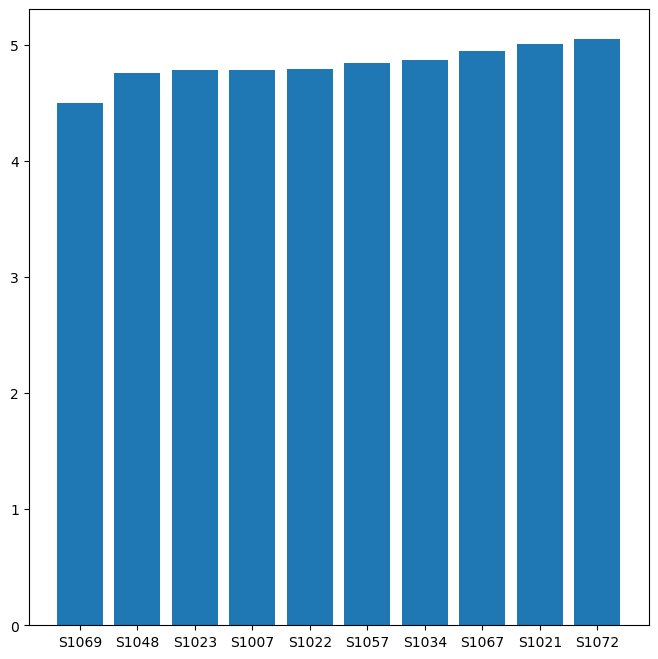

,shipment_id,carrier,month,weight_kg,distance_km,fuel_l,delay_days,on_time,eff_km_per_l
0,S1000,BlueRail,2025-11,3320,883,152.80,2.0,0,5.778796
1,S1001,AdriaticLog,2025-10,1852,716,136.38,3.0,0,5.250037
2,S1002,AdriaticLog,2025-05,1285,804,111.82,3.0,0,7.190127
3,S1003,AdriaticLog,2025-06,2265,802,151.88,5.0,0,5.280485
4,S1004,BlueRail,2025-06,4391,599,87.95,3.0,0,6.810688
...,...,...,...,...,...,...,...,...,...
75,S1075,NordCargo,2025-01,808,1402,166.36,1.0,0,8.427507
76,S1076,BlueRail,2025-06,377,1347,171.04,7.0,0,7.875351
77,S1077,FastShip,2025-11,4350,1761,284.20,0.0,1,6.196341
78,S1078,FastShip,2025-08,2157,975,115.81,7.0,0,8.418962


In [19]:
#1
df = pd.read_csv("shipments.csv")
val_manc = pd.isnull(df).sum()
print("Valori mancanti per colonna: ", val_manc)
#2
df = df.dropna()
#3
df["eff_km_per_l"] = df["distance_km"]/df["fuel_l"]
#4
filtraggio = df[(df["weight_kg"]>2500) & (df["eff_km_per_l"] >6.5)]
n = len(filtraggio)
print("Numero di righe ottenute: ", n)
#5
df_ordinato = df.sort_values(by="eff_km_per_l").head(10)
plt.figure(figsize=(8,8))
plt.bar(df_ordinato["shipment_id"], df_ordinato["eff_km_per_l"])
plt.show()
df

# Esercizio 5

Si utilizzi lo stesso dataset `shipments.csv`, opportunamente pulito come nell’esercizio precedente.

Svolgere le seguenti richieste:

1. Determinare il numero di righe e di colonne del dataset ed eliminare la colonna `shipment_id`.
2. Individuare il `carrier` più frequente nel dataset.
3. Calcolare la media di `delay_days` per ciascun `carrier` e ordinare i risultati dal valore medio più alto al più basso.
4. Rappresentare la distribuzione di `delay_days` per ciascun `carrier` mediante un boxplot.
5.  Calcolare la percentuale di spedizioni puntuali (`on_time = 1`) e non puntuali (`on_time = 0`)
**usando una list comprehension**, e rappresentare tali percentuali con un grafico a torta (pie chart).


In [22]:
#1
df = pd.read_csv("shipments.csv")
df = df.dropna()
dimensioni = df.shape
print("Numero righe e colonne del dataset ", dimensioni)
df = df.drop(columns="shipment_id")
#2
carrer_freq = df["carrier"].mode()[0]
print("Carrier più frequente nel df: ", carrer_freq)
#3
df["media"] = df.groupby("carrier")["delay_days"].mean()
df_ordinato_media = df.sort_values(by="media", ascending=True)
df_ordinato_media

Numero righe e colonne del dataset  (72, 8)
Carrier più frequente nel df:  AdriaticLog


,carrier,month,weight_kg,distance_km,fuel_l,delay_days,on_time,media
0,BlueRail,2025-11,3320,883,152.80,2.0,0,NaN
1,AdriaticLog,2025-10,1852,716,136.38,3.0,0,NaN
2,AdriaticLog,2025-05,1285,804,111.82,3.0,0,NaN
3,AdriaticLog,2025-06,2265,802,151.88,5.0,0,NaN
4,BlueRail,2025-06,4391,599,87.95,3.0,0,NaN
...,...,...,...,...,...,...,...,...
75,NordCargo,2025-01,808,1402,166.36,1.0,0,NaN
76,BlueRail,2025-06,377,1347,171.04,7.0,0,NaN
77,FastShip,2025-11,4350,1761,284.20,0.0,1,NaN
78,FastShip,2025-08,2157,975,115.81,7.0,0,NaN


## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.  

1. Stima i parametri della retta del tipo  

   $$
   y = a \cdot x + b
   $$  

2. Plotta i punti originali e la retta ottenuta.  

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


In [24]:
x = np.array([
  0.0, 0.5, 1.0, 1.5, 2.0, 2.5,
  3.0, 3.5, 4.0, 4.5, 5.0, 5.5,
  6.0, 6.5, 7.0, 7.5, 8.0, 8.5,
  9.0, 9.5, 10.0
])

y = np.array([
   1.2,  2.4,  4.8,  6.5,  7.6,  9.9,
  11.3, 13.6, 15.1, 16.8, 19.2, 20.5,
  22.9, 24.1, 26.6, 28.0, 29.8, 31.7,
  33.5, 35.2, 36.9
])

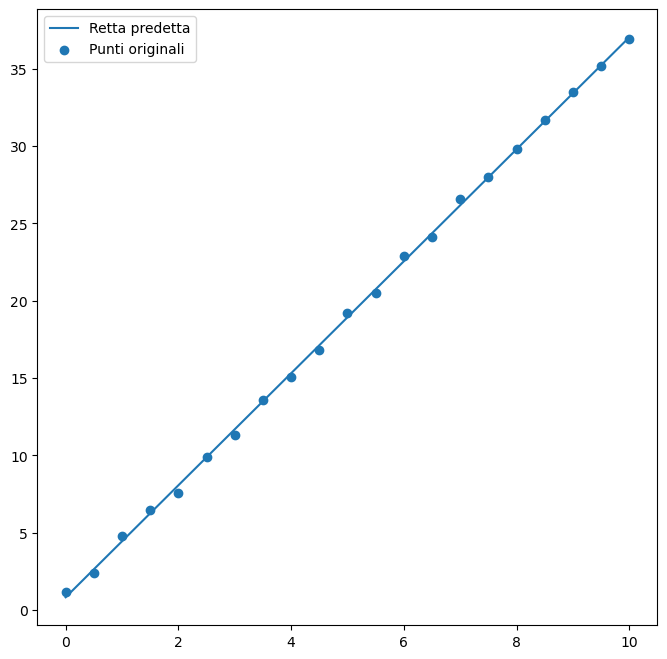

In [25]:
def modello_retta(x,a,b):
    return a*x +b
parametri, cov = curve_fit(modello_retta, x, y)
a_pred, b_pred = parametri
y_pred = modello_retta(x, a_pred, b_pred)
plt.figure(figsize=(8,8))
plt.plot(x, y_pred, label="Retta predetta")
plt.scatter(x, y, label="Punti originali")
plt.legend()
plt.show()
mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)
